In [1]:
import warnings
warnings.simplefilter("ignore")

import tensorflow as tf
print(tf.__version__)

2.20.0


# PCA

In [2]:
from tensorflow import keras # type: ignore
from keras.datasets import mnist
import numpy as np
np.set_printoptions(precision=2)

import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [4]:
x_train = x_train.astype(np.float32) / 255.
x_test = x_test.astype(np.float32) / 255.

In [5]:
x_train_flat = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_flat = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train_flat.shape)
print(x_test_flat.shape)

(60000, 784)
(10000, 784)


In [6]:
from sklearn.preprocessing import MinMaxScaler
s = MinMaxScaler().fit(x_train_flat)
x_train_scaled = s.transform(x_train_flat)

In [7]:
from sklearn.decomposition import PCA

def mnist_pca(x_data, n_components):
    pca = PCA(n_components=n_components)

    fit_pca = pca.fit(x_data)

    print("Variance explained with {0} components:".format(n_components), 
          round(sum(fit_pca.explained_variance_ratio_), 2))
    
    return fit_pca, fit_pca.transform(x_data)


In [8]:
pca_full, mnist_data_full = mnist_pca(x_train_scaled, 784)

Variance explained with 784 components: 1.0


Text(0, 0.5, 'Proportion of variance explained')

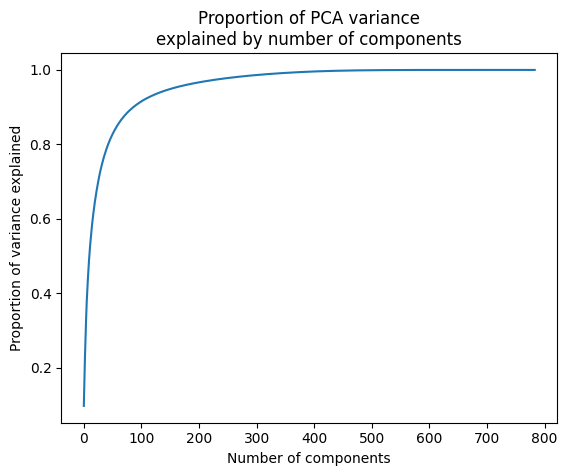

In [9]:
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.title("Proportion of PCA variance\nexplained by number of components")
plt.xlabel("Number of components")
plt.ylabel("Proportion of variance explained")

In [10]:
pca_2, mnist_data_2 = mnist_pca(x_train_scaled, 2)

Variance explained with 2 components: 0.17


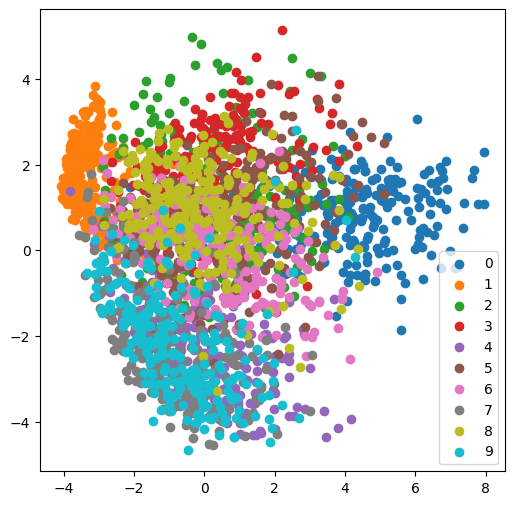

In [13]:
num_images_pre_class = 250
fig = plt.figure(figsize = (6, 6))
for number in list(range(10)):
    mask = y_train == number
    x_data = mnist_data_2[mask, 0][:num_images_pre_class]
    y_data = mnist_data_2[mask, 1][:num_images_pre_class]
    plt.scatter(x_data, y_data, label = number, alpha=1)
plt.legend()

In [14]:
pca_64, mnist_data_64 = mnist_pca(x_train_scaled, 64)

Variance explained with 64 components: 0.86


In [15]:
x_test_scaled = s.transform(x_test_flat)

In [16]:
x_test_flat_64 = pca_64.transform(x_test_scaled)
x_test_reconstructed_64 = pca_64.inverse_transform(x_test_flat_64)

In [17]:
x_test_reconstructed_64.shape

(10000, 784)

In [18]:
true = x_test_scaled
reconstructed = x_test_reconstructed_64

In [19]:
def mse_reconstructed(true, reconstructed):
    return np.sum(np.power(true - reconstructed, 2) / true.shape[1])

In [20]:
mse_reconstructed(true, reconstructed)

90.51656

# Auto Encoder

In [22]:
from keras.layers import Input, Dense
from keras.models import Model

In [27]:
ENCODING_DIM = 64

# Encoder
inputs = Input(shape=(784, ))
encoded = Dense(ENCODING_DIM, activation='sigmoid')(inputs)
encoder_model = Model(inputs, encoded, name='encoder')

# Decoder
encoded_inputs = Input(shape=(ENCODING_DIM, ), name='encoding')
reconstruction = Dense(784, activation='sigmoid')(encoded_inputs)
decoder_model = Model(encoded_inputs, reconstruction, name='decoder')

# Full Model
outputs = decoder_model(encoder_model(inputs))
full_model = Model(inputs, outputs, name='full_ae')

In [28]:
full_model.compile(optimizer='rmsprop',
                   loss = 'binary_crossentropy',
                   metrics=['accuracy'])

In [29]:
history = full_model.fit(x_train_flat, x_train_flat, shuffle=True, epochs=1, batch_size=32)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0122 - loss: 0.2723


In [30]:
full_model.summary()

Model: "full_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,402 (790.64 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,202 (395.32 KB)

In [31]:
encoded_images = encoder_model.predict(x_test_flat)
encoded_images.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step


(10000, 64)

In [32]:
encoded_images[0]

array([0.97, 0.97, 0.92, 0.92, 0.98, 0.97, 0.95, 0.98, 0.98, 0.98, 0.97,
       0.97, 0.97, 0.96, 0.97, 0.98, 0.96, 0.64, 0.98, 0.95, 0.97, 0.98,
       0.97, 0.97, 0.95, 0.97, 0.96, 0.98, 0.64, 0.98, 0.97, 0.97, 0.98,
       0.98, 0.98, 0.96, 0.98, 0.99, 0.97, 0.97, 0.81, 0.97, 0.95, 0.95,
       0.92, 0.75, 0.82, 0.97, 0.97, 0.95, 0.98, 0.98, 0.97, 0.98, 0.96,
       0.98, 0.97, 0.97, 0.98, 0.85, 0.96, 0.97, 0.96, 0.83],
      dtype=float32)

In [36]:
decoded_images = full_model.predict(x_test_flat)
mse_reconstructed(decoded_images, x_test_flat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


660.9545

In [37]:
ENCODING_DIM = 64
HIDDEN_DIM = 256

# Encoder
inputs = Input(shape=(784, ))
encoder_hidden = Dense(HIDDEN_DIM, activation='relu')(inputs)
encoded = Dense(ENCODING_DIM, activation='sigmoid')(encoder_hidden)
encoder_model = Model(inputs, encoded, name='encoder')

# Decoder
encoded_inputs = Input(shape=(ENCODING_DIM, ), name='encoding')
decoder_hidden = Dense(HIDDEN_DIM, activation='relu')(encoded_inputs)
reconstruction = Dense(784, activation='sigmoid')(decoder_hidden)
decoder_model = Model(encoded_inputs, reconstruction, name='decoder')

# Full Model
outputs = decoder_model(encoder_model(inputs))
full_model = Model(inputs, outputs, name='full_ae')

In [38]:
full_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

In [39]:
history = full_model.fit(x_train_flat, x_train_flat, shuffle=True, epochs=5, batch_size=32)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.0099 - loss: 0.2266
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0120 - loss: 0.1606
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0113 - loss: 0.1362
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0123 - loss: 0.1238
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0107 - loss: 0.1155


In [41]:
decoded_images = full_model.predict(x_test_flat)
mse_reconstructed(decoded_images, x_test_flat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


155.76839

In [44]:
def train_ae_epochs(num_epochs = 1):
    EENCODING_DIM = 64
    HIDDEN_DIM = 256

    # Encoder
    inputs = Input(shape=(784, ))
    encoder_hidden = Dense(HIDDEN_DIM, activation='relu')(inputs)
    encoded = Dense(ENCODING_DIM, activation='sigmoid')(encoder_hidden)
    encoder_model = Model(inputs, encoded, name='encoder')

    # Decoder
    encoded_inputs = Input(shape=(ENCODING_DIM, ), name='encoding')
    decoder_hidden = Dense(HIDDEN_DIM, activation='relu')(encoded_inputs)
    reconstruction = Dense(784, activation='sigmoid')(decoder_hidden)
    decoder_model = Model(encoded_inputs, reconstruction, name='decoder')

    # Full Model
    outputs = decoder_model(encoder_model(inputs))
    full_model = Model(inputs, outputs, name='full_ae')
    
    full_model.compile(optimizer='rmsprop',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])
    
    mse_res = []
    for i in range(num_epochs):
        history = full_model.fit(x_train_flat, x_train_flat, shuffle=True, epochs=1, batch_size=32)

        decoded_images = full_model.predict(x_test_flat)
        reconstruction_loss = mse_reconstructed(decoded_images, x_test_flat)
        mse_res.append(reconstruction_loss)
        print("Reconstruction loss after epoch {0} is {1}".format(i+1, reconstruction_loss))

    return mse_res
        

In [47]:
mse_loss = train_ae_epochs(10)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.0101 - loss: 0.2250
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Reconstruction loss after epoch 1 is 383.7418518066406
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0105 - loss: 0.1629
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Reconstruction loss after epoch 2 is 273.3986511230469
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0108 - loss: 0.1404
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Reconstruction loss after epoch 3 is 232.55503845214844
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0114 - loss: 0.1276
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Reconstruction loss after epoch 4 is 188.5372314453125
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0118 - loss: 0.1188
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Reconstruction loss after epoch 5 is 166.5629119873047
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.0104 - loss: 0.1126
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Reconstruction l

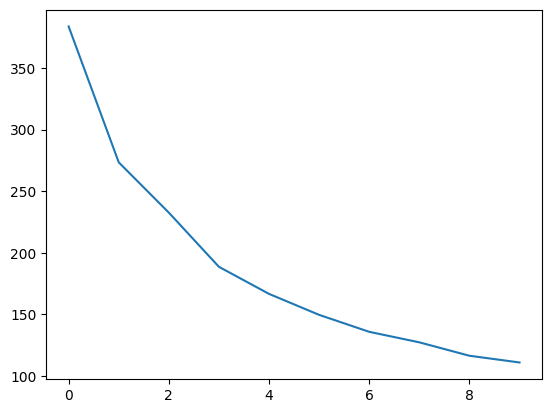

In [48]:
plt.plot(range(len(mse_loss)), mse_loss)